# EXPLORATORIO
# Wavelet Denoising on mock cubes

# 0. Importaciones y Configuración

## 0.1. Importaciones

In [1]:
from astropy.io import fits
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
import os
import sys
from dicts_wavelets import transformaciones_1d, transformaciones_2d, filtros
from scipy.optimize import curve_fit
from astropy.modeling.models import SmoothlyBrokenPowerLaw1D
from astropy.modeling.fitting import LevMarLSQFitter

sys.path.append('../../src')

from wavelet_denoising import Wavelet2D1DTransform, Denoiser2D1D

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/mock_cubes'

mkdir -p failed for path /.matplotlib: [Errno 30] Read-only file system: '/.matplotlib'
Matplotlib created a temporary cache directory at /var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/matplotlib-umtd_dge because there was an issue with the default path (/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


## 0.2. Configuración de Matplotlib

In [2]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 12,
    "figure.figsize": (3.5, 2.625), # 4:3 ratio for single-column
    "savefig.dpi": 600
})


# 1. Carga del cubo e información

In [179]:
CUBE_NAME = 'isolated_AC5_N500_width1/isolated_AC5_N500_width1_noisy'

In [183]:
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))
cube = hdu[0].data
cube = np.squeeze(cube)
cube = np.nan_to_num(cube, nan=0.0) # Se reemplazan los NaN por 0

y = cube.copy() # Cubo de referencia de estadísticas. (No tenemos por lo que usamos el cubo original)

print(
    'Shape: ', cube.shape
    )

print(
    'BSCALE: ', hdu[0].header['BSCALE']
)

ref_freq = hdu[0].header['RESTFRQ']
channel_width = hdu[0].header['CDELT4']
c = const.c.to('km/s').value

channel_width_km_s = channel_width * c / ref_freq

print(
    'Channel width: ', channel_width_km_s
)

Shape:  (200, 200, 200)
BSCALE:  1.0
Channel width:  9.999894769283895


In [175]:
# Vamos a calcular el peak SNR del cubo para verificar que esté dentro del rango de valores
# aceptables para el modelo.

rms_noise = np.std(cube[0:7])
peak_signal = np.max(cube)
peak_snr = peak_signal / rms_noise
print(f'Peak SNR: {peak_snr}')

Peak SNR: 92.53376770019531


# 2. Denoising

In [176]:
denoiser = Denoiser2D1D(
    threshold_type='soft', # Tipo de umbral
    verbose=False
    )

## 2.1. Iterative Denoising

In [177]:
# --- PARAMS --- #
THRESHOLD_LEVEL = 5

### 2.1.1. Noisy Cube Original

In [178]:
result = denoiser.denoise(
    x=cube,
    y=cube.copy(),
    method='iterative',
    threshold_level=THRESHOLD_LEVEL
)
best_model = result[0]

hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))

# Restauramos el eje degenerado de Stokes para que la shape de los datos
# vuelva a coincidir con el header WCS original (NAXIS=4) y CARTA lo abra bien.
best_model_4d = best_model[:, np.newaxis, :, :]
assert best_model_4d.shape == hdu[0].data.shape, \
    f'Shape mismatch: {best_model_4d.shape} vs {hdu[0].data.shape}'

hdu[0].data = best_model_4d.astype(np.float32)
hdu.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_wavelets_soft_{THRESHOLD_LEVEL}_denoised.fits'), overwrite=True)
hdu.close()

## 2.2. Simple Denoising

### 2.2.1. Noisy Cube Original

In [12]:
result = denoiser.denoise(
    x=cube,
    y=cube.copy(),
    method='simple',
    threshold_level=THRESHOLD_LEVEL
)
best_model = result

hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))

# Restauramos el eje degenerado de Stokes para que la shape de los datos
# vuelva a coincidir con el header WCS original (NAXIS=4) y CARTA lo abra bien.
best_model_4d = best_model[:, np.newaxis, :, :]
assert best_model_4d.shape == hdu[0].data.shape, \
    f'Shape mismatch: {best_model_4d.shape} vs {hdu[0].data.shape}'

hdu[0].data = best_model_4d.astype(np.float32)
hdu.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_wavelets_soft_{THRESHOLD_LEVEL}_SIMPLE_denoised.fits'), overwrite=True)
hdu.close()

## 2.2. Negative Cube

In [9]:
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))
cube = hdu[0].data
cube = np.squeeze(cube)
cube = cube * (-1)
cube = np.nan_to_num(cube, nan=0.0) # Se reemplazan los NaN por 0

y = cube.copy() # Cubo de referencia de estadísticas. (No tenemos por lo que usamos el cubo original)

print(cube.shape)

(20, 200, 200)


In [10]:
denoiser = Denoiser2D1D(
    threshold_type='soft', # Tipo de umbral
    verbose=True, # Mostrar mensajes de progreso
    )

result = denoiser.denoise(
    x=cube,
    y=cube.copy(),
    method='iterative',
    threshold_level=THRESHOLD_LEVEL
)
best_model = result[0]

hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))

# Restauramos el eje degenerado de Stokes para que la shape de los datos
# vuelva a coincidir con el header WCS original (NAXIS=4) y CARTA lo abra bien.
best_model_4d = best_model[:, np.newaxis, :, :]
assert best_model_4d.shape == hdu[0].data.shape, \
    f'Shape mismatch: {best_model_4d.shape} vs {hdu[0].data.shape}'

hdu[0].data = best_model_4d.astype(np.float32)
hdu.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_wavelets_soft_{THRESHOLD_LEVEL}_denoised_negative.fits'), overwrite=True)
hdu.close()

Number of 2D wavelet scales set to 7 (maximum value allowed by input image)
Number of 1D wavelet scales set to 4 (maximum value allowed by input image)

--- [ PERFORMING ITERATIVE DENOISING ] ---

----[ Denoising with ITERATIVE SOFT THRESHOLDING ]----

[*] Trying with plateau condition: 1 consecutive stable residuals needed for convergence


--- [ DE-NOISING ITERATION #1 ] ---

(*) Decomposing noisy data into wavelet coefficients
(*) The gradient in the first iteration is 0
(*) Reconstructing the new signal coefficients into the real space
(*) Applying the positivity constraint
(*) Repeating these steps for subsequent iterations
(*) Aperture Flux: 3.423e-02, Clean Flux: -4.355e-01, Residual STD: 4.827e-05


--- [ DE-NOISING ITERATION #2 ] ---

(*) Updating model with gradient with respect to data
(*) Calculating weights for each iteration (except #1) to account for the soft thresholding bias
(*) Aperture Flux: 7.422e-02, Clean Flux: -4.355e-01, Residual STD: 4.827e-05

flux: 0.07422107

# 3. Definición de umbral

## 3.1. Original Cube

In [118]:
# Apertura cubo.
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))

data_positive = hdu[0].data # Data original del cubo.
data_negative = hdu[0].data * (-1) # Data multiplicada * -1.

# Se eliminan valores infinitos y NaNs. Después, se quita el eje de Stokes.
flux_values_positive = data_positive[np.isfinite(data_positive)].flatten()
flux_values_negative = data_negative[np.isfinite(data_negative)].flatten()

# Se eliminan los 0.
flux_values_positive = flux_values_positive[flux_values_positive != 0]
flux_values_negative = flux_values_negative[flux_values_negative != 0]

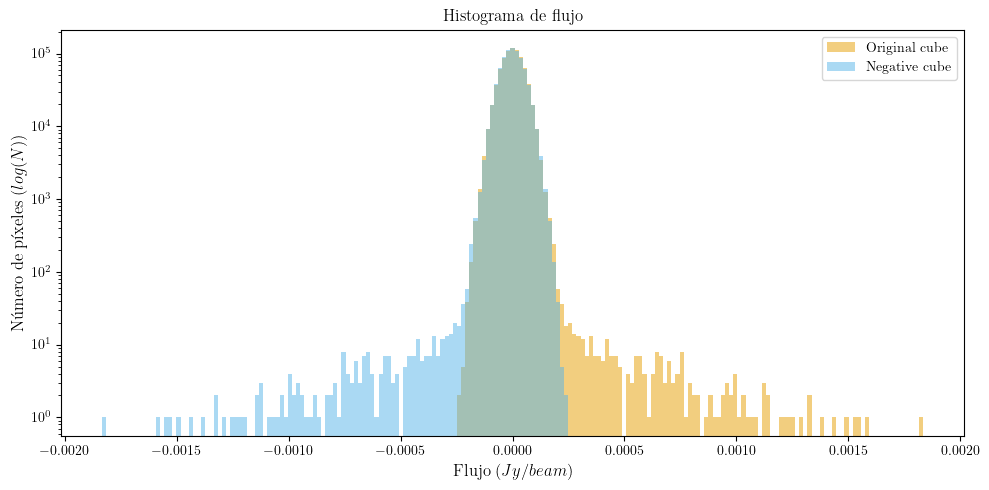

In [119]:
# Realizamos un plot para poder observar ambas distribuciones.
plt.figure(figsize=(10, 5))

counts_positive, bin_edges_positive, _  = plt.hist(
    flux_values_positive,
    bins=np.linspace(flux_values_negative.min(), flux_values_positive.max(), 200),
    linewidth=0.3,
    label='Original cube',
    alpha=0.5
    )
counts_negative, bin_edges_negative, _  = plt.hist(
    flux_values_negative,
    bins=np.linspace(flux_values_negative.min(), flux_values_positive.max(), 200),
    linewidth=0.3,
    label='Negative cube',
    alpha=0.5
    )


plt.xlabel('Flujo ($Jy/beam$)')
plt.ylabel('Número de píxeles ($log(N)$)')
plt.yscale('log')
plt.title('Histograma de flujo')

plt.legend()
plt.tight_layout()
plt.show()

La zona de ruido es la parte simétrica, véase, en donde se intersectan las dos distribuciones. Vamos a hacer un acercamiento a esta zona para poder observarla mejor. 

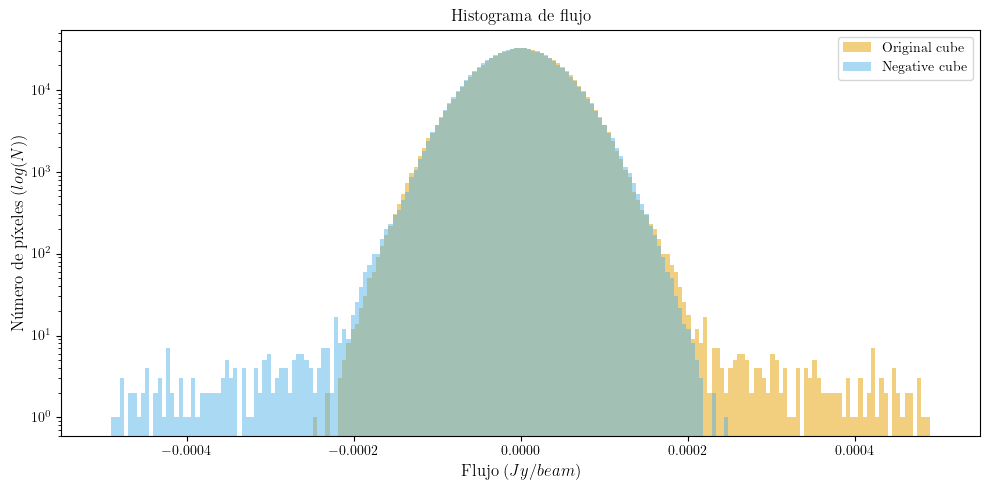

In [120]:
# Realizamos un plot para poder observar ambas distribuciones.
plt.figure(figsize=(10, 5))

counts_positive, bin_edges_positive, _  = plt.hist(
    flux_values_positive,
    bins=np.linspace(-0.0005, 0.0005, 200),
    linewidth=0.3,
    label='Original cube',
    alpha=0.5
    )
counts_negative, bin_edges_negative, _  = plt.hist(
    flux_values_negative,
    bins=np.linspace(-0.0005, 0.0005, 200),
    linewidth=0.3,
    label='Negative cube',
    alpha=0.5
    )


plt.xlabel('Flujo ($Jy/beam$)')
plt.ylabel('Número de píxeles ($log(N)$)')
plt.yscale('log')
plt.title('Histograma de flujo')

plt.legend()
plt.tight_layout()
plt.show()

Vamos a observar sólo la parte positiva, que es la que nos interesa. En ese caso, se considera que el cubo negativo es una buena demostración del ruido, debido a que es simétrico y que no existen fuentes de flujo negativo.

In [159]:
flux_values_negative_fit = flux_values_negative[flux_values_negative > 0]
flux_values_positive_fit = flux_values_positive[flux_values_positive > 0]

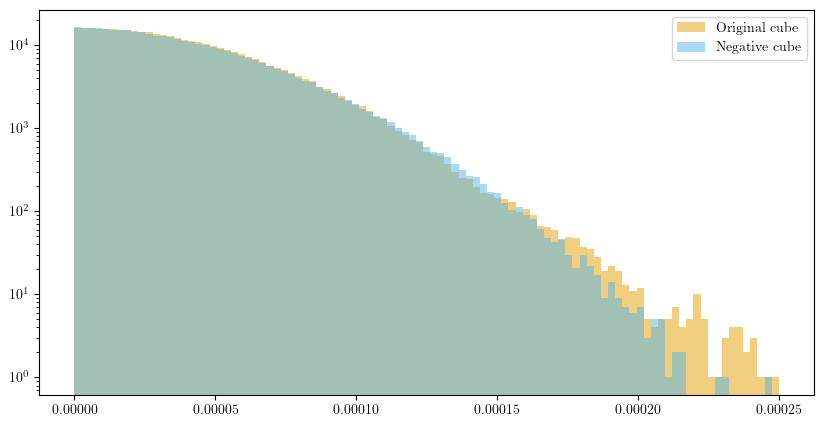

In [122]:
fig, ax = plt.subplots(figsize=(10, 5))

counts_positive, bin_edges_positive, _ = ax.hist(
    flux_values_positive_fit,
    bins=np.linspace(0, 0.00025, 100),
    label='Original cube',
    alpha=0.5
    )

bin_centers_positive = (bin_edges_positive[:-1] + bin_edges_positive[1:]) / 2
mask_positive = (bin_centers_positive > 0) & (counts_positive > 0)

counts_negative, bin_edges_negative, _ = ax.hist(
    flux_values_negative_fit,
    bins=np.linspace(0, 0.00025, 100),
    label='Negative cube',
    alpha=0.5
    )

bin_centers_negative = (bin_edges_negative[:-1] + bin_edges_negative[1:]) / 2
mask_negative = (bin_centers_negative > 0) & (counts_negative > 0)

ax.legend()
plt.yscale('log')

(-0.5, 1.05)

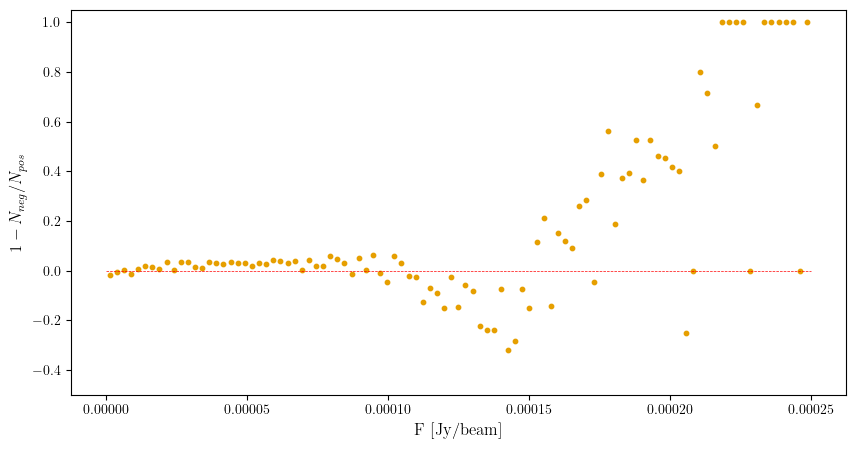

In [123]:
R = 1 - (counts_negative / counts_positive)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hlines(0,0,0.00025,color='red',linewidth=0.5, linestyle='--')
ax.scatter(bin_centers_negative, R, s=10)
ax.set_ylabel('$1- N_{neg}/N_{pos}$')
ax.set_xlabel('F [Jy/beam]')
ax.set_ylim(-0.5,1.05)

Aquí tenemos algo a tener en cuenta: se presenta una zona en donde los valores negativos son mayores que los positivos. Esto en sí no tiene sentido físico, por lo que hay que estudiar las posibles causas.

### 3.1.1. Estudio posibles causas exceso de counts en cubo negativo

#### 3.1.1.a. Sesgo en la línea base (offset negativo del continuo)

Si la sustracción de continuo dejó un residuo levemente negativo (o si hay un offset global), la mediana del ruido no es exactamente 0, sino algún valor $\mu <0$. Esto haría que:
- La cola negativa del cubo tenga más píxeles y se extienda más lejos.
- Al multiplicar por -1, ese exceso aparece justo en el rango positivo cercano a 0, y entonces `counts_negative > counts_positive`.
Esto implicaría que el umbral derivado a partir de la cola del cubo negativo estaría **sobreestimado**, por lo que se perdería señal débil.

In [124]:
noise_channels = cube[0:7]
noise_pixels = noise_channels[noise_channels !=0]
print('Media: ', np.mean(noise_pixels))
print('Mediana: ', np.median(noise_pixels))
print('Desviación estándar: ', np.std(noise_pixels))
print('Mínimo: ', np.min(noise_pixels))
print('Máximo: ', np.max(noise_pixels))
print('Rango: ', np.max(noise_pixels) - np.min(noise_pixels))
print('Cociente mediana/desviación estándar: ', np.median(noise_pixels) / np.std(noise_pixels))

Media:  2.6452773e-07
Mediana:  5.5420804e-07
Desviación estándar:  4.828416e-05
Mínimo:  -0.00024630674
Máximo:  0.00023728797
Rango:  0.00048359472
Cociente mediana/desviación estándar:  0.011478051


Debido a los valores, esto no se trata de un sesgo en la línea base.

#### 3.1.1.b. "Negative bowl" del CLEAN
En los cubos generados con interferometría sintética, las baselines cortas faltantes producen un *negative bowl* alrededor de la emisión extendida. Es decir, los píxeles vecinos a una fuente brillante quedan sistemáticamente con flujo negativo.
Esto implicaría que el cubo negativo "hereda" esos píxeles del bowl en su cola positiva, generando un exceso espurio. Aquí el problema no es el ruido sino un artefacto sistemático correlacionado con la señal.

Para revisar si nos encontramos con este caso, vamos a realizar un **mapeo de los píxeles más negativos**. Si están concentrados alrededor de la fuente, es un negative bowl. Si están distribuidos aleatoriament, es ruido genuino.

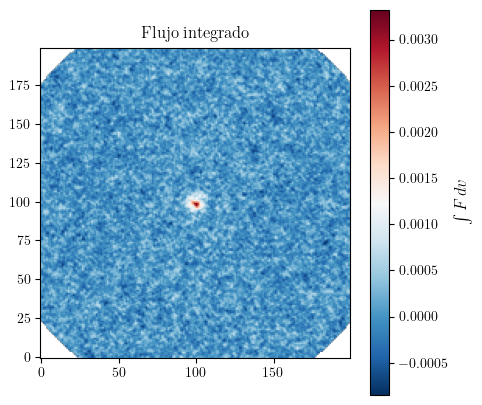

In [ ]:
data_positive_copy = np.squeeze(data_positive, axis=1)
data_positive_copy = data_positive_copy[]

plt.figure(figsize=(5, 5))
plt.imshow(data_positive_copy.sum(axis=0), origin='lower', cmap='RdBu_r')
#plt.xlim(50, 150)
#plt.ylim(50, 150)
plt.colorbar(label=r'$\int F\,dv$')
plt.title('Flujo integrado')
plt.show()

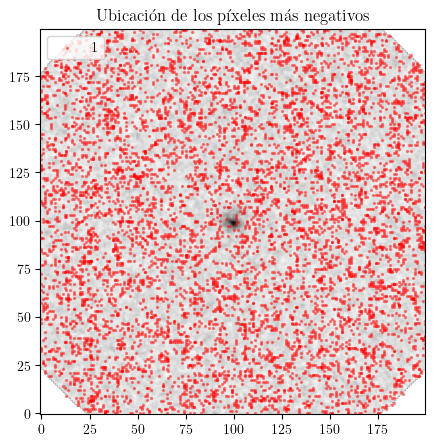

In [136]:
percentil = np.nanpercentile(data_positive_copy, 1)  # 1% más negativo
mask = data_positive_copy < percentil
chans, ys, xs = np.where(mask)

plt.figure(figsize=(5, 5))
plt.imshow(data_positive_copy.sum(axis=0), origin='lower', cmap='Greys')
plt.scatter(xs, ys, s=2, c='red', alpha=0.4, label='1% más negativo')
plt.legend()
plt.title('Ubicación de los píxeles más negativos')
plt.show()

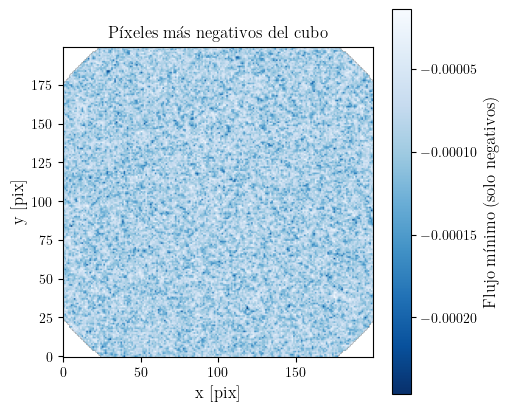

In [137]:
min_map = data_positive_copy.min(axis=0)        # valor mínimo a lo largo del eje espectral
min_map = np.where(min_map < 0, min_map, np.nan)  # solo negativos

plt.figure(figsize=(5, 5))
plt.imshow(min_map, origin='lower', cmap='Blues_r')
plt.colorbar(label='Flujo mínimo (solo negativos)')
plt.title('Píxeles más negativos del cubo')
plt.xlabel('x [pix]'); plt.ylabel('y [pix]')
plt.show()

No aparece una distribución estilo "negative bowl".

#### 3.1.1.c. Ruido no perfectamente Gaussiano/correlacionado

El ruido de un cubo interferométrico no es pixel-a-pixel independiente: está correlacionado a la escala del beam. Si la generación del ruido en el mock no respeta exactamente la PSF, o si tiene una componente de ruido $1/f$, *flicker*, etc., la distribución puede tener **skewness** no nula. Eso produce asimetrías reales en el histograma.

Calculemos la skewness de una región del cubo sin emisión.

In [140]:
from scipy.stats import skew
import numpy as np

noise_pixels = cube[0:7][cube[0:7] != 0]

s = skew(noise_pixels)
n = len(noise_pixels)
se_skew = np.sqrt(6 * n * (n-1) / ((n-2) * (n+1) * (n+3)))  # error estándar bajo H0: gauss
z = s / se_skew  # cuántas sigmas de detección
print(f'Skewness = {s:.4f} ± {se_skew:.4f}  (z = {z:.1f})')

Skewness = -0.0213 ± 0.0047  (z = -4.5)


El ruido es esencialmente simétrico.

#### 3.1.1.d. Fluctuaciones estadísticas en las colas

Cuando se realiza zoom al rango positivo ($>0$) y se filtra `flux_values>0$, quedan la mitad de los píxeles originales del cubo. Si además se observa el rango donde el histograma cae a counts bajos, los errores Poisson por bin pueden ser comparables a la diferencia observada.

**Test rápido:** graficar los counts con barras de error. Si las barras de error se solapan en la región `neg > pos`, **es ruido estadístico**, no un sesgo real.

(100, 10000.0)

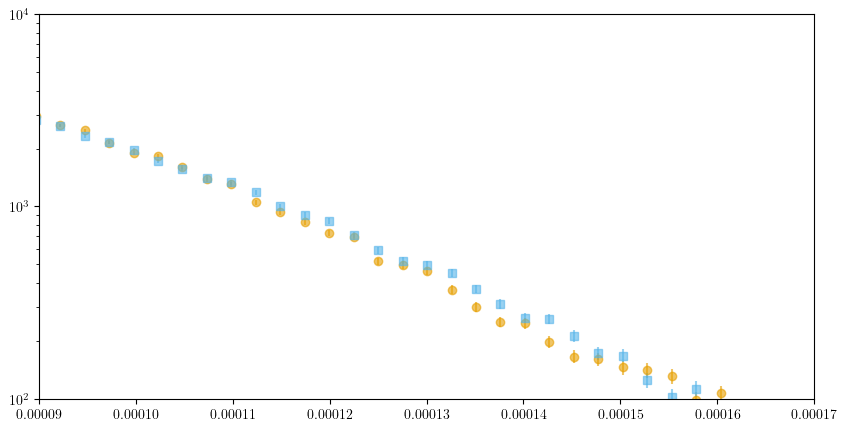

In [151]:
plt.figure(figsize=(10, 5))
plt.errorbar(bin_centers_positive, counts_positive, 
             yerr=np.sqrt(counts_positive), fmt='o', label='Positive', alpha=0.6)
plt.errorbar(bin_centers_negative, counts_negative, 
             yerr=np.sqrt(counts_negative), fmt='s', label='Negative', alpha=0.6)
plt.yscale('log')
plt.xlim(0.00009,0.00017)
plt.ylim(100,10e3)

No existe solapamiento.

#### 3.1.1.e. Test de Kolmogorov-Smirnov
En vez de comparar bin-a-bin, se pueden comparar las distribuciones completas. Si $p > 0.05$: las distribuciones son **estadísticamente compatibles**. La asimetría visual es una ilusión del histograma. En ese caso se puede seguir utilizando el cubo negativo como proxy del ruido sin problemas (excepto por la señal real, que vive en valores altos).

In [154]:
flux_values_positive_ks = flux_values_positive_fit[
    (flux_values_positive_fit > 0) &
    (flux_values_positive_fit < 0.00017)
    ]
flux_values_negative_ks = flux_values_negative_fit[
    (flux_values_negative_fit > 0) &
    (flux_values_negative_fit < 0.00017)
    ]

In [155]:
from scipy.stats import ks_2samp

stat, pvalue = ks_2samp(flux_values_positive_ks, flux_values_negative_ks)
print(f'KS: D = {stat:.4f}, p-value = {pvalue:.3g}')

KS: D = 0.0051, p-value = 8.58e-05


El valor de p es considerable, pero si observamos D, la máxima diferencia es del 0.5%. Eso es ridículamente bajo. Por lo tanto, podemos considerar que el cubo negativo es un proxy del ruido válido.

#### 3.1.1.f. Q-Q Plot

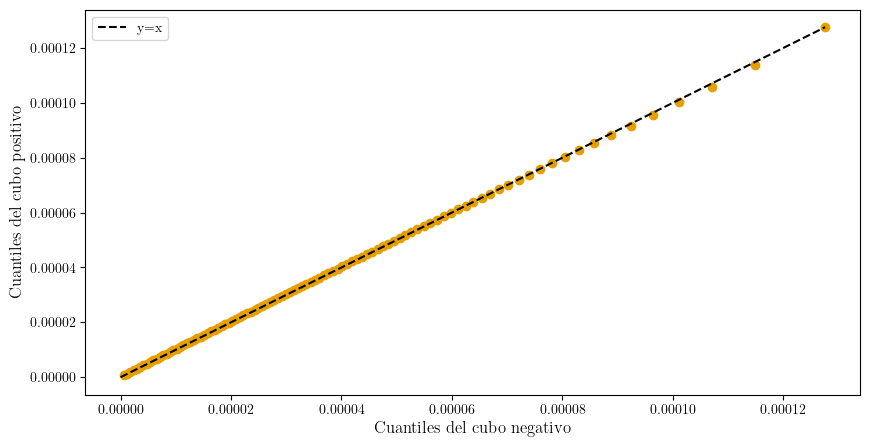

In [157]:
q = np.linspace(0.01, 0.99, 100)
q_pos = np.quantile(flux_values_positive_fit, q)
q_neg = np.quantile(flux_values_negative_fit, q)

plt.figure(figsize=(10, 5))
plt.plot(q_neg, q_pos, 'o')
plt.plot([0, q_pos.max()], [0, q_pos.max()], 'k--', label='y=x')
plt.xlabel('Cuantiles del cubo negativo')
plt.ylabel('Cuantiles del cubo positivo')
plt.legend()

El cubo negativo es básicamente un proxy perfecto.

#### 3.1.1.g. Conclusión del análisis

La asimetría visual que se está observando en el histograma se debe a una combinación de:
1. Fluctuaciones estadísticas Poisson bin-a-bin (especialmente notables en escala log).
2. la acumulación de varios efectos pequeños (offset + skewness).
3. El efecto óptico de mirar en escala logarítmica, donde diferencias del orden del 1% parecen mucho más grandes de lo que son.

## 3.2. Denoised Cube

In [170]:
hdu_positive_original = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}_wavelets_soft_{THRESHOLD_LEVEL}_denoised.fits'))
data_positive_original = hdu_positive_original[0].data
flux_values_positive_original = data_positive_original[np.isfinite(data_positive_original)].flatten()
flux_values_positive_original = flux_values_positive_original[flux_values_positive_original != 0] # Se eliminan los 0

hdu_negative_original = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}_wavelets_soft_{THRESHOLD_LEVEL}_denoised_negative.fits'))
data_negative_original = hdu_negative_original[0].data
flux_values_negative_original = data_negative_original[np.isfinite(data_negative_original)].flatten()
flux_values_negative_original = flux_values_negative_original[flux_values_negative_original != 0] # Se eliminan los 0

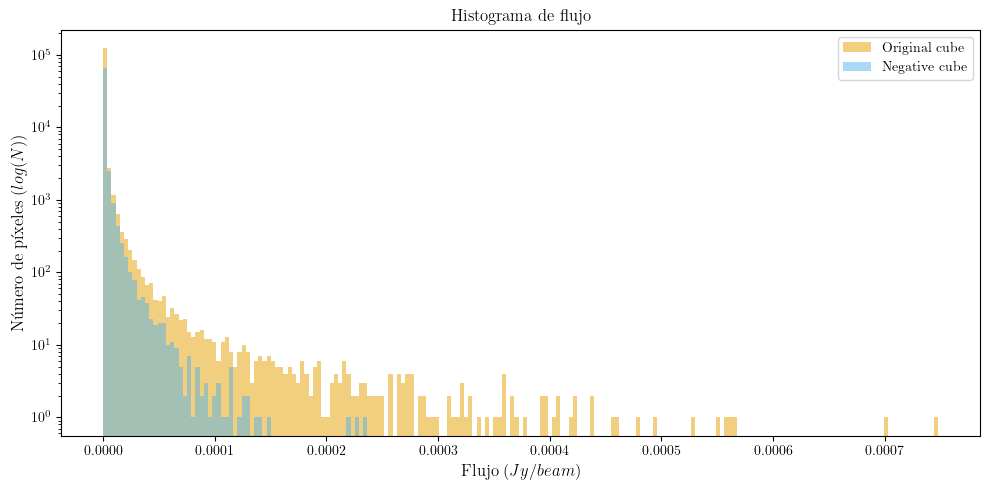

In [172]:
plt.figure(figsize=(10, 5))

counts_positive, bin_edges_positive, _  = plt.hist(
    flux_values_positive_original,
    bins=np.linspace(flux_values_negative_original.min(), flux_values_positive_original.max(), 200),
    linewidth=0.3,
    label='Original cube',
    alpha=0.5
    )
counts_negative, bin_edges_negative, _  = plt.hist(
    flux_values_negative_original,
    bins=np.linspace(flux_values_negative_original.min(), flux_values_positive_original.max(), 200),
    linewidth=0.3,
    label='Negative cube',
    alpha=0.5
    )


plt.xlabel('Flujo ($Jy/beam$)')
plt.ylabel('Número de píxeles ($log(N)$)')
plt.yscale('log')
plt.title('Histograma de flujo')

plt.legend()
plt.tight_layout()
plt.show()

In [75]:
flux_values_negative_fit = flux_values_negative_original[flux_values_negative_original > 0]
flux_values_positive_fit = flux_values_positive_original[flux_values_positive_original > 0]

Bines usados para estimar el factor: 19 / 79
Mediana del cociente pos/neg (zona de ruido): 1.866
Factor de escala aplicado a la negativa: x 1.866


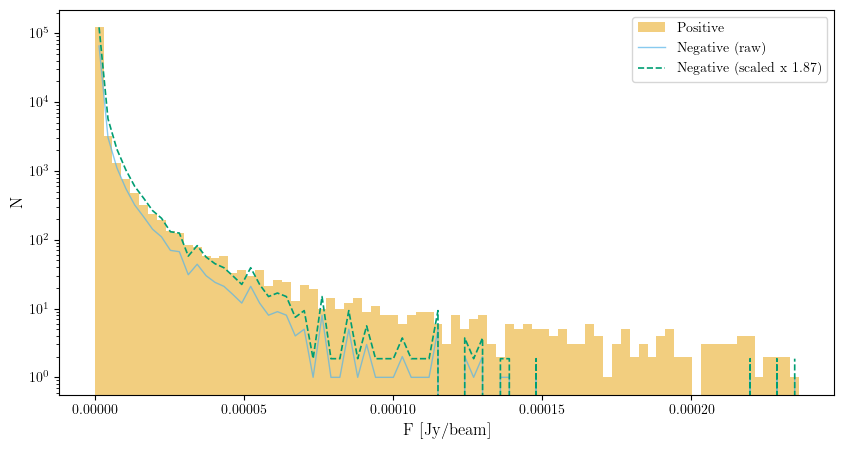

In [76]:
# Histogramas con counts crudos (sin density). Escalamos la parte negativa
# para que coincida con la positiva en la zona de ruido y así el cociente
# N_pos / N_neg quede centrado en 1 cuando las distribuciones son iguales,
# y se aleje de 1 cuando aparece señal en el lado positivo.
#
# Usamos la MEDIANA del cociente bin-a-bin (en los bines donde ambos
# histogramas tienen suficiente estadística) en lugar de max/max:
# la mediana es robusta frente a outliers en bines individuales (sea por
# fluctuación estadística del pico o por la propia señal en la cola
# positiva), mientras que max/max está dominado por un único bin.

fig, ax = plt.subplots(figsize=(10, 5))

bins_fit = np.linspace(0, flux_values_negative_fit.max(), 80)

counts_positive, bin_edges_positive, _ = ax.hist(
    flux_values_positive_fit,
    bins=bins_fit,
    alpha=0.5,
    label='Positive',
)

bin_centers_positive = (bin_edges_positive[:-1] + bin_edges_positive[1:]) / 2
mask_positive = (bin_centers_positive > 0) & (counts_positive > 0)

counts_negative_raw, bin_edges_negative = np.histogram(
    flux_values_negative_fit, bins=bins_fit,
)
bin_centers_negative = (bin_edges_negative[:-1] + bin_edges_negative[1:]) / 2

# Factor de escala robusto: mediana del cociente pos/neg en bines con
# estadística suficiente. La señal en el lado positivo solo afecta unos
# pocos bines de la cola, no la mediana.
MIN_COUNTS_FOR_RATIO = 10
ratio_mask = (counts_positive >= MIN_COUNTS_FOR_RATIO) & (
    counts_negative_raw >= MIN_COUNTS_FOR_RATIO
)
ratio_pos_neg = counts_positive[ratio_mask] / counts_negative_raw[ratio_mask]
median_ratio = float(np.median(ratio_pos_neg))
scale_factor = median_ratio  # multiplica a la parte negativa
counts_negative = counts_negative_raw * scale_factor

print(f'Bines usados para estimar el factor: {ratio_mask.sum()} / {ratio_mask.size}')
print(f'Mediana del cociente pos/neg (zona de ruido): {median_ratio:.3f}')
print(f'Factor de escala aplicado a la negativa: x {scale_factor:.3f}')

ax.plot(
    bin_centers_negative, counts_negative_raw,
    color='C1', linewidth=1, alpha=0.7,
    label='Negative (raw)',
)
ax.plot(
    bin_centers_negative, counts_negative,
    '--', color='C2', linewidth=1.2,
    label=f'Negative (scaled x {scale_factor:.2f})',
)

mask_negative = (bin_centers_negative > 0) & (counts_negative > 0)

ax.set_yscale('log')
ax.set_xlabel('F [Jy/beam]')
ax.set_ylabel('N')
ax.legend()

Text(0.5, 0, 'F [Jy/beam]')

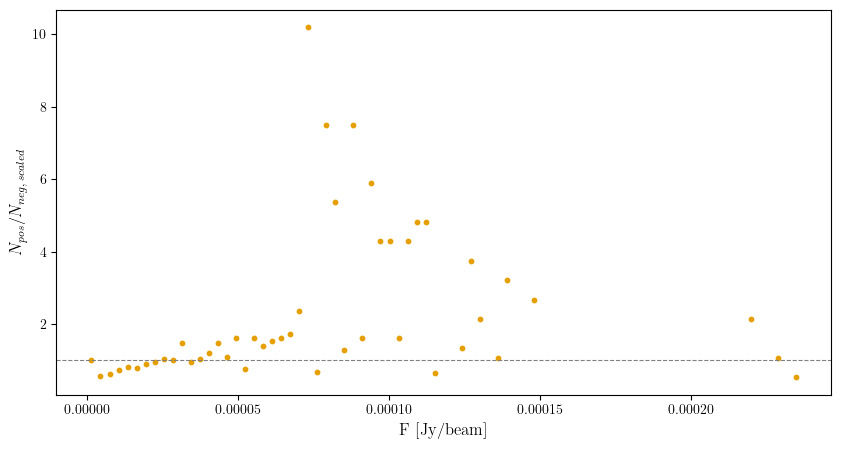

In [77]:
# counts_negative ya viene escalado al máximo de counts_positive,
# por lo que el cociente está centrado en 1 en la zona de ruido y se aleja de
# 1 a medida que aparece señal.
counts_positive_mod = counts_positive.copy()
counts_positive_mod[counts_positive_mod == 0] = 1
counts_negative_mod = counts_negative.copy()
counts_negative_mod[counts_negative_mod == 0] = 1

div_counts = counts_positive_mod / counts_negative_mod
div_counts_neg = counts_negative_mod / counts_positive_mod

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(bin_centers_negative[mask_negative], div_counts[mask_negative], s=10)
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylabel('$N_{pos}/N_{neg,\,scaled}$')
ax.set_xlabel('F [Jy/beam]')

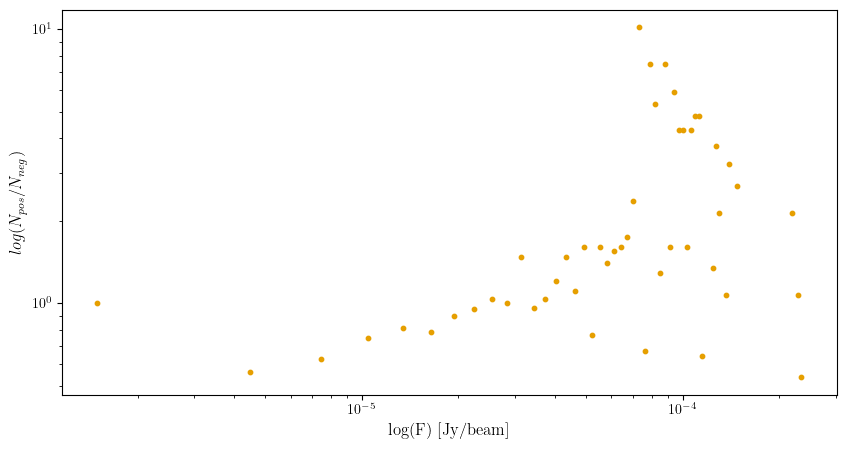

In [78]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(bin_centers_negative[mask_negative], div_counts[mask_negative], s=10)
ax.set_ylabel('$log(N_{pos}/N_{neg})$')
ax.set_xlabel('log(F) [Jy/beam]')
ax.set_yscale('log')
ax.set_xscale('log')